# Per‑region Benth OU + Neural Networks (Model 1: NN calibration)

Your CSV has **many regions** (multiple rows per date). This notebook trains **one independent model per region**:

- Fit seasonal mean $s_r(t)$ (harmonic regression) for each region $r$
- Residuals $X_{r,t}=T_{r,t}-s_r(t)$
- Train a neural network that predicts $(\kappa_{r,t},\sigma_{r,t})$ from a rolling window and DOY features

Outputs per region:
- training / test NLL curves
- learned $\kappa_{r,t}$ and $\sigma_{r,t}$ over time
- standardized residual diagnostics
- optional Monte‑Carlo simulation + HDD example

**Note:** This is the "Model 1" approach (NN calibrates OU parameters).

In [4]:
# --- Imports ---
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from dataclasses import dataclass

np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

## 1) Load your CSV

Expected columns:
- `date`
- `region_code`
- `temp`

If your column names differ, rename them below.

In [5]:
CSV_PATH = "../EDA/region_avg.csv"  # <- change if needed
DATE_COL = "date"
REGION_COL = "region_code"
TEMP_COL = "daily_avg_temperature"

df_raw = pd.read_csv(CSV_PATH)
df_raw = df_raw.rename(columns={DATE_COL:"date", REGION_COL:"region_code", TEMP_COL:"daily_avg_temperature"})

df_raw["date"] = pd.to_datetime(df_raw["date"], errors="coerce")
df_raw["temp"] = pd.to_numeric(df_raw["daily_avg_temperature"], errors="coerce")
df_raw["region_code"] = pd.to_numeric(df_raw["region_code"], errors="coerce")

df_raw = df_raw.dropna(subset=["date","temp","region_code"]).copy()
df_raw["region_code"] = df_raw["region_code"].astype(int)

print(df_raw.head())
print(df_raw.tail())
print("shape:", df_raw.shape)
print("regions:", df_raw["region_code"].nunique())


        date  region_code  daily_avg_temperature  temp
0 1970-01-01           11                  -2.40 -2.40
1 1970-01-01           24                  -2.50 -2.50
2 1970-01-01           28                   4.40  4.40
3 1970-01-01           44                  -3.35 -3.35
4 1970-01-01           52                  -0.85 -0.85
             date  region_code  daily_avg_temperature      temp
158009 2024-12-31           28               5.875000  5.875000
158010 2024-12-31           32               4.795455  4.795455
158011 2024-12-31           44              -0.102632 -0.102632
158012 2024-12-31           52               5.662500  5.662500
158013 2024-12-31           53               8.276667  8.276667
shape: (151743, 4)
regions: 8


## 2) Helper functions

In [6]:
def design_matrix_seasonality(dates: pd.Series, K: int = 3, include_trend: bool = True) -> np.ndarray:
    n = len(dates)
    doy = dates.dt.dayofyear.values.astype(float)
    parts = [np.ones(n)]
    if include_trend:
        t = np.arange(n) / 365.0
        parts.append(t)
    for k in range(1, K+1):
        parts.append(np.sin(2*np.pi*k*doy/365.0))
        parts.append(np.cos(2*np.pi*k*doy/365.0))
    return np.column_stack(parts)

def fit_seasonal_mean(dates: pd.Series, temp: np.ndarray, K: int = 3):
    X = design_matrix_seasonality(dates, K=K, include_trend=True)
    y = temp.astype(float)
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    s_hat = X @ beta
    return s_hat, beta

def doy_features(dates: pd.Series, harmonics: int = 3) -> np.ndarray:
    doy = dates.dt.dayofyear.values.astype(float)
    feats = []
    for k in range(1, harmonics+1):
        feats.append(np.sin(2*np.pi*k*doy/365.0))
        feats.append(np.cos(2*np.pi*k*doy/365.0))
    return np.column_stack(feats)

def make_windows(x: np.ndarray, doy_feat: np.ndarray, window: int = 30):
    x = np.asarray(x, dtype=np.float32)
    doy_feat = np.asarray(doy_feat, dtype=np.float32)
    N, F = doy_feat.shape
    xs, xt, y, idx = [], [], [], []
    for t in range(window, N-1):
        inp = np.concatenate([x[t-window:t], doy_feat[t]], axis=0)
        xs.append(inp)
        xt.append(x[t])
        y.append(x[t+1])
        idx.append(t)
    return np.stack(xs), np.array(xt), np.array(y), np.array(idx)

class CalibNet(nn.Module):
    def __init__(self, in_dim: int, hidden: int = 64, kappa_max: float = 0.5):
        super().__init__()
        self.kappa_max = kappa_max
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 2),  # raw_kappa, raw_sigma
        )
        self.softplus = nn.Softplus()

    def forward(self, x):
        raw = self.net(x)
        kappa = self.kappa_max * torch.sigmoid(raw[:, 0]) + 1e-6
        sigma = self.softplus(raw[:, 1]) + 1e-6
        return kappa, sigma

def ou_nll_euler(x_t, x_tp1, kappa, sigma, dt: float = 1.0):
    mean = x_t - kappa * x_t * dt
    var = (sigma ** 2) * dt
    var = torch.clamp(var, min=1e-6)  # prevents log(0)/div0
    resid2 = (x_tp1 - mean) ** 2
    resid2 = torch.clamp(resid2, max=1e8)
    return 0.5 * (torch.log(var) + resid2 / var).mean()


## 3) Per‑region training configuration

In [7]:
# Model / data hyperparameters
K_HARMONICS = 3       # seasonal mean harmonics
DOY_HARMONICS = 3     # NN time-of-year features
WINDOW = 30           # rolling residual window length
DT = 1.0              # daily step
EPOCHS = 800          # increase if you want
LR = 1e-3
HIDDEN = 64
KAPPA_MAX = 0.5       # daily kappa bound

# Regions to train (edit if you want a subset)
regions = sorted(df_raw["region_code"].unique().tolist())
print("Total regions:", len(regions))
print("Regions:", regions)


Total regions: 8
First 20: [11, 24, 27, 28, 32, 44, 52, 53]


## 4) Train one model per region

This loop will:
1. Filter data to one region
2. Fit seasonal mean $s_r(t)$
3. Compute residuals $X_{r,t}$
4. Standardize residuals (stability)
5. Train CalibNet via OU likelihood
6. Save model weights + store diagnostics


In [8]:
results = []              # summary rows
models = {}               # region -> model (in-memory)
region_artifacts = {}     # region -> dict of arrays for plots/diagnostics

OUT_DIR = "per_region_models"
os.makedirs(OUT_DIR, exist_ok=True)

for r in regions:
    dfr = df_raw[df_raw["region_code"] == r].sort_values("date").reset_index(drop=True)

    # Ensure one value per date for this region
    dfr = dfr.groupby("date", as_index=False)["temp"].mean()
    if len(dfr) < (WINDOW + 60):
        results.append({"region": r, "status":"skipped (too short)", "n_days": len(dfr)})
        continue

    # Fit seasonal mean and residuals
    s_hat, beta = fit_seasonal_mean(dfr["date"], dfr["temp"].values, K=K_HARMONICS)
    x = (dfr["temp"].values - s_hat).astype(np.float32)

    # Standardize residuals (important!)
    x_mean = float(np.mean(x))
    x_std  = float(np.std(x) + 1e-8)
    xz = (x - x_mean) / x_std

    # Build features/windows
    doy_feat = doy_features(dfr["date"], harmonics=DOY_HARMONICS)
    X_in, x_t, x_tp1, idx_t = make_windows(xz, doy_feat, window=WINDOW)

    # Train/test split
    N = X_in.shape[0]
    split = int(0.8 * N)
    X_train = torch.tensor(X_in[:split], dtype=torch.float32, device=device)
    x_t_train = torch.tensor(x_t[:split], dtype=torch.float32, device=device)
    x_tp1_train = torch.tensor(x_tp1[:split], dtype=torch.float32, device=device)

    X_test = torch.tensor(X_in[split:], dtype=torch.float32, device=device)
    x_t_test = torch.tensor(x_t[split:], dtype=torch.float32, device=device)
    x_tp1_test = torch.tensor(x_tp1[split:], dtype=torch.float32, device=device)

    # Model
    model = CalibNet(in_dim=X_train.shape[1], hidden=HIDDEN, kappa_max=KAPPA_MAX).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=LR)

    # Train
    train_curve, test_curve, epochs_logged = [], [], []
    for epoch in range(1, EPOCHS+1):
        model.train()
        kappa, sigma = model(X_train)
        loss = ou_nll_euler(x_t_train, x_tp1_train, kappa, sigma, dt=DT)

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        if epoch % 50 == 0 or epoch == 1:
            model.eval()
            with torch.no_grad():
                k_te, s_te = model(X_test)
                loss_te = ou_nll_euler(x_t_test, x_tp1_test, k_te, s_te, dt=DT)
            train_curve.append(float(loss.item()))
            test_curve.append(float(loss_te.item()))
            epochs_logged.append(epoch)

    # Evaluate on all windows
    model.eval()
    with torch.no_grad():
        k_all, s_all = model(torch.tensor(X_in, dtype=torch.float32, device=device))
    k_all = k_all.detach().cpu().numpy()
    s_all = s_all.detach().cpu().numpy()

    # Standardized residuals on test
    with torch.no_grad():
        k_te, s_te = model(X_test)
        mean_te = x_t_test - k_te * x_t_test * DT
        z_te = (x_tp1_test - mean_te) / (s_te * np.sqrt(DT))
    z_te = z_te.detach().cpu().numpy()

    # Save model + region params needed to simulate back in original units
    save_path = os.path.join(OUT_DIR, f"calibnet_region_{r}.pt")
    torch.save({
        "state_dict": model.state_dict(),
        "window": WINDOW,
        "doy_harmonics": DOY_HARMONICS,
        "k_harmonics": K_HARMONICS,
        "beta": beta,
        "x_mean": x_mean,
        "x_std": x_std,
        "kappa_max": KAPPA_MAX,
        "hidden": HIDDEN,
    }, save_path)

    models[r] = model
    region_artifacts[r] = {
        "df": dfr,
        "beta": beta,
        "s_hat": s_hat,
        "x": x,            # original residual
        "xz": xz,          # standardized residual
        "idx_t": idx_t,
        "kappa_all": k_all,
        "sigma_all": s_all,
        "train_curve": train_curve,
        "test_curve": test_curve,
        "epochs_logged": epochs_logged,
        "z_test": z_te,
        "save_path": save_path,
    }

    results.append({
        "region": r,
        "status":"ok",
        "n_days": len(dfr),
        "train_nll_last": train_curve[-1] if len(train_curve) else np.nan,
        "test_nll_last": test_curve[-1] if len(test_curve) else np.nan,
        "z_mean": float(np.mean(z_te)),
        "z_std": float(np.std(z_te)),
        "model_path": save_path,
    })

summary = pd.DataFrame(results).sort_values(["status","region"])
summary.head(), summary.tail(), summary.shape


(   region status  n_days  train_nll_last  test_nll_last    z_mean     z_std  \
 0      11     ok   20089       -0.198148       0.635269  0.036696  1.631856   
 1      24     ok   20089       -0.201722       0.603723  0.019154  1.622982   
 2      27     ok   15170       -0.197129       0.906216  0.026705  1.762808   
 3      28     ok   20089       -0.180931       0.505119  0.041732  1.533553   
 4      32     ok   16039       -0.210775       0.697648  0.047710  1.692898   
 
                                 model_path  
 0  per_region_models/calibnet_region_11.pt  
 1  per_region_models/calibnet_region_24.pt  
 2  per_region_models/calibnet_region_27.pt  
 3  per_region_models/calibnet_region_28.pt  
 4  per_region_models/calibnet_region_32.pt  ,
    region status  n_days  train_nll_last  test_nll_last    z_mean     z_std  \
 3      28     ok   20089       -0.180931       0.505119  0.041732  1.533553   
 4      32     ok   16039       -0.210775       0.697648  0.047710  1.692898   
 

### Summary table

In [9]:
summary

,region,status,n_days,train_nll_last,test_nll_last,z_mean,z_std,model_path
0,11,ok,20089,-0.198148,0.635269,0.036696,1.631856,per_region_models/calibnet_region_11.pt
1,24,ok,20089,-0.201722,0.603723,0.019154,1.622982,per_region_models/calibnet_region_24.pt
2,27,ok,15170,-0.197129,0.906216,0.026705,1.762808,per_region_models/calibnet_region_27.pt
3,28,ok,20089,-0.180931,0.505119,0.041732,1.533553,per_region_models/calibnet_region_28.pt
4,32,ok,16039,-0.210775,0.697648,0.047710,1.692898,per_region_models/calibnet_region_32.pt
5,44,ok,20089,-0.248074,0.360381,0.030358,1.470661,per_region_models/calibnet_region_44.pt
6,52,ok,20089,-0.145878,0.328326,0.038181,1.388054,per_region_models/calibnet_region_52.pt
7,53,ok,20089,-0.191396,0.428913,0.006855,1.498278,per_region_models/calibnet_region_53.pt


## 5) Plot diagnostics for a chosen region

In [10]:
# Pick a region to inspect
REGION_TO_PLOT = summary[summary["status"]=="ok"]["region"].iloc[0]
REGION_TO_PLOT


np.int64(11)

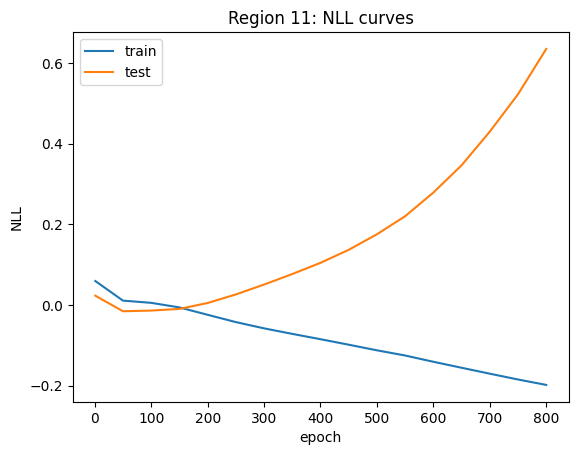

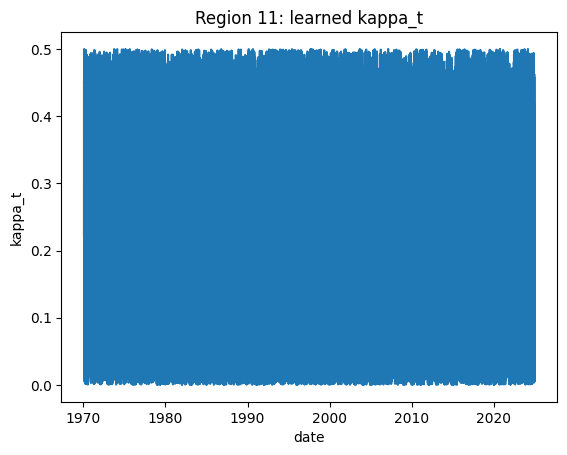

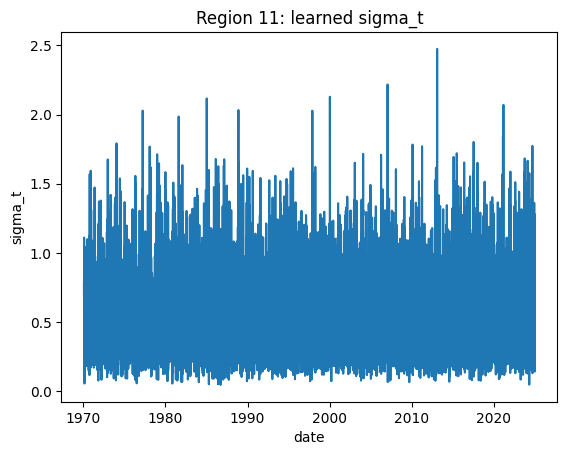

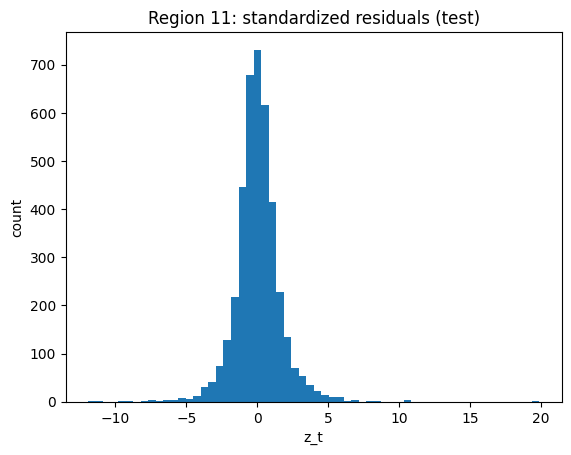

z mean: 0.036696165800094604 z std: 1.6318564414978027
saved model: per_region_models/calibnet_region_11.pt


In [11]:
art = region_artifacts[REGION_TO_PLOT]
dfr = art["df"]

dates_k = dfr.loc[art["idx_t"], "date"].values

plt.figure()
plt.plot(art["epochs_logged"], art["train_curve"], label="train")
plt.plot(art["epochs_logged"], art["test_curve"], label="test")
plt.title(f"Region {REGION_TO_PLOT}: NLL curves")
plt.xlabel("epoch")
plt.ylabel("NLL")
plt.legend()
plt.show()

plt.figure()
plt.plot(dates_k, art["kappa_all"])
plt.title(f"Region {REGION_TO_PLOT}: learned kappa_t")
plt.xlabel("date")
plt.ylabel("kappa_t")
plt.show()

plt.figure()
plt.plot(dates_k, art["sigma_all"])
plt.title(f"Region {REGION_TO_PLOT}: learned sigma_t")
plt.xlabel("date")
plt.ylabel("sigma_t")
plt.show()

plt.figure()
plt.hist(art["z_test"], bins=60)
plt.title(f"Region {REGION_TO_PLOT}: standardized residuals (test)")
plt.xlabel("z_t")
plt.ylabel("count")
plt.show()

print("z mean:", float(np.mean(art["z_test"])), "z std:", float(np.std(art["z_test"])))
print("saved model:", art["save_path"])


## 6) Optional: simulate temperatures for that region and compute HDD example

This uses the trained NN to produce $(\kappa_t,\sigma_t)$ step-by-step. Residuals are simulated in **standardized units** and then mapped back to original units.

In [12]:
@dataclass
class SimConfig:
    horizon_days: int = 90
    n_paths: int = 2000
    base_temp: float = 18.0
    tick_value: float = 1.0
    dt: float = 1.0

def simulate_region(art, model, start_index: int, sim: SimConfig):
    dfr = art["df"].copy()
    beta = art["beta"]
    x_mean, x_std = float(np.mean(art["x"])), float(np.std(art["x"]) + 1e-8)

    # Start from observed day
    x0 = float(art["x"][start_index])
    x0z = (x0 - x_mean) / x_std

    start_date = dfr.loc[start_index, "date"]
    dates = pd.date_range(start_date, periods=sim.horizon_days+1, freq="D")

    # seasonal mean future
    X_design = design_matrix_seasonality(pd.Series(dates), K=K_HARMONICS, include_trend=True)
    s_future = X_design @ beta

    # history window from standardized residuals
    xz_series = ((art["x"] - x_mean) / x_std).astype(np.float32)
    hist = xz_series[max(0, start_index-WINDOW):start_index]
    if len(hist) < WINDOW:
        hist = np.pad(hist, (WINDOW-len(hist), 0), mode="edge")

    X_paths_z = np.zeros((sim.n_paths, sim.horizon_days+1), dtype=np.float32)
    T_paths = np.zeros((sim.n_paths, sim.horizon_days+1), dtype=np.float32)

    X_paths_z[:, 0] = x0z
    T_paths[:, 0] = s_future[0] + x0

    for t in range(sim.horizon_days):
        feat = doy_features(pd.Series([dates[t]]), harmonics=DOY_HARMONICS).astype(np.float32).reshape(-1)
        inp = np.concatenate([hist[-WINDOW:], feat], axis=0)[None, :]
        inp_t = torch.tensor(inp, dtype=torch.float32, device=device)

        with torch.no_grad():
            kappa_t, sigma_t = model(inp_t)
        kappa_t = float(kappa_t.item())
        sigma_t = float(sigma_t.item())

        eps = np.random.randn(sim.n_paths).astype(np.float32)
        x_next_z = X_paths_z[:, t] - kappa_t * X_paths_z[:, t] * sim.dt + sigma_t * np.sqrt(sim.dt) * eps

        X_paths_z[:, t+1] = x_next_z

        # map back to original residual + temp
        x_next = x_next_z * x_std + x_mean
        T_paths[:, t+1] = s_future[t+1] + x_next

        hist = np.append(hist, x_next_z.mean())

    return T_paths

SIM_REGION = REGION_TO_PLOT
sim_cfg = SimConfig(horizon_days=90, n_paths=3000, base_temp=18.0, tick_value=1.0)

art = region_artifacts[SIM_REGION]
model = models[SIM_REGION]
# start from last 20% of sample
start_index = int(len(art["df"]) * 0.85)

T_paths = simulate_region(art, model, start_index=start_index, sim=sim_cfg)
T_paths.shape


(3000, 91)

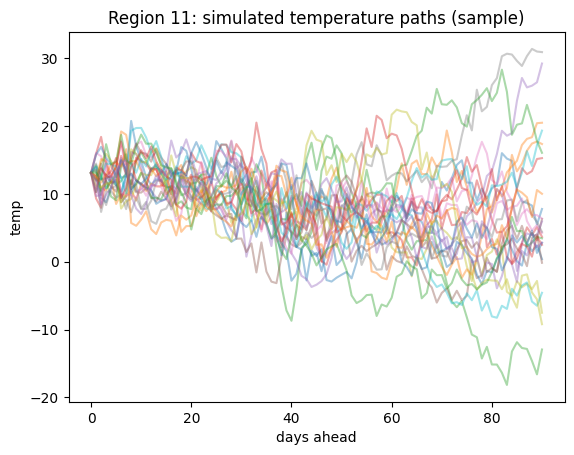

Expected HDD: 985.0858154296875
Std HDD: 225.34780883789062
Expected payoff: 985.0858154296875


In [13]:
plt.figure()
for i in range(25):
    plt.plot(T_paths[i], alpha=0.4)
plt.title(f"Region {SIM_REGION}: simulated temperature paths (sample)")
plt.xlabel("days ahead")
plt.ylabel("temp")
plt.show()

K_base = sim_cfg.base_temp
hdd = np.maximum(0.0, K_base - T_paths[:, 1:]).sum(axis=1)
payoff = sim_cfg.tick_value * hdd
print("Expected HDD:", float(hdd.mean()))
print("Std HDD:", float(hdd.std()))
print("Expected payoff:", float(payoff.mean()))
